# Model vs Manual QC Exploration

This notebook is a starting point for comparing model predictions against manual QC labels.

Workflow:
1. Load a target file range (default: Jul-Dec 2025).
2. Run model prediction in dry-run mode with overwrite behavior enabled (no file writes).
3. Compare model outputs against current/manual flags.
4. Build disagreement tables for plotting and deeper analysis.

In [1]:

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from IPython.display import display

from io_utils import load_qc_csvs
from predict_with_saved_model import predict_with_model
from prediction_comparison import load_and_predict, compare_predictions, format_metrics_table

sns.set_theme(style="whitegrid")

DATA_ROOT = Path("data")
TEST_MONTHS = ["2026-01", "2026-02"]
# TEST_MONTHS = [f"{year}-{month:02d}" for year in range(2023, 2026) for month in range(1, 13)]
TARGETS = ["Flag_GHI", "Flag_DNI", "Flag_DHI"]
TS_COL = "YYYY-MM-DD--HH:MM:SS"

## Notebook Structure

This notebook follows this workflow:

1. **Load Data**: Load both regular files and injected error files separately
2. **Generate Predictions**: Run model predictions on both datasets
3. **Create Comprehensive DataFrames**: Each dataframe contains:
   - All minute-level irradiance data (GHI, DNI, DHI)
   - Manual QC flags (Flag_GHI, Flag_DNI, Flag_DHI)
   - Model predictions (Flag_GHI_model, Flag_DNI_model, Flag_DHI_model)
4. **Analyze & Visualize**: Compare model vs manual flags with metrics, confusion matrices, and time series plots

In [2]:
def get_target_files_for_months(data_root: Path, target_months: list[str]) -> list[str]:
    """Return sorted file paths for exact target months like 'YYYY-MM'."""
    pattern = re.compile(r"STW_(\d{4})-(\d{2})_QC\.csv$")
    selected = []
    target_set = set(target_months)

    for p in sorted(data_root.glob("**/*_QC.csv")):
        if "injected_error" in p.parts:
            continue

        m = pattern.match(p.name)
        if not m:
            continue

        year_month = f"{m.group(1)}-{m.group(2)}"
        if year_month in target_set:
            selected.append(str(p))

    return selected


# Load regular files
file_paths = get_target_files_for_months(DATA_ROOT, TEST_MONTHS)
print(f"Selected {len(file_paths)} regular file(s) for test months: {', '.join(TEST_MONTHS)}")
for fp in file_paths:
    print(" -", fp)

if not file_paths:
    raise ValueError("No files were selected. Check TEST_MONTHS values and file names.")

# Load raw data and get model predictions
print("\nLoading raw data and generating model predictions...")
raw_regular = load_qc_csvs(file_paths, header_rows_skip=43, ts_col=TS_COL)
comparison_results_regular = load_and_predict(file_paths, TARGETS)

# Build comprehensive dataframe with data, manual flags, and model predictions
print("Building comprehensive dataframe for regular files...")
df_regular = raw_regular.copy()
df_regular['_source_file'] = None  # Will be populated per row
df_regular['_raw_ts'] = df_regular[TS_COL]

# Add model predictions to the dataframe
for target in TARGETS:
    if target in comparison_results_regular:
        pred_df = comparison_results_regular[target][[f"{target}_predicted", "_raw_ts"]].copy()
        pred_df = pred_df.rename(columns={f"{target}_predicted": f"{target}_model"})
        df_regular = df_regular.merge(pred_df, left_on='_raw_ts', right_on='_raw_ts', how='left')

print(f"Regular dataframe shape: {df_regular.shape}")
print(f"Columns: {', '.join(df_regular.columns[:20])}...")  # Show first 20 columns
df_regular.head()

Selected 2 regular file(s) for test months: 2026-01, 2026-02
 - data\STW_2026\STW_2026-01_QC.csv
 - data\STW_2026\STW_2026-02_QC.csv

Loading raw data and generating model predictions...

Loading 2 file(s)...
Loaded 84960 samples from 2 file(s)
Adding features...


c:\Users\atomi\Desktop\Capstone Project\solar_features.py:513: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  temp['Timestamp_dt'].view('int64') / 1e9,



--- Predicting Flag_GHI ---
Model loaded from models\model_Flag_GHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84912 GOOD (99.9%), 48 BAD (0.1%)
  Mean confidence (P(GOOD)): 0.999

--- Predicting Flag_DNI ---
Model loaded from models\model_Flag_DNI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84729 GOOD (99.7%), 231 BAD (0.3%)
  Mean confidence (P(GOOD)): 0.997

--- Predicting Flag_DHI ---
Model loaded from models\model_Flag_DHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84231 GOOD (99.1%), 729 BAD (0.9%)
  Mean confidence (P(GOOD)): 0.991


Building comprehensive dataframe for regular files...
Regular dataframe shape: (84960, 24)
Columns: year.fractionofyear, dayofyear.fractionofday, YYYY-MM-DD--HH:MM:SS, SZA, AZM, ETR_(W/m^2), DNI_ClearSkyModel_(W/m^2), GHI, Flag_GHI, GHI_Calc, Flag_GHI_Calc, DrHI_Calc, Flag_DrHI_Calc, DNI, Flag_DNI, DHI, Flag_DHI, Temperature, Flag_Temperature, _source_file...


,year.fractionofyear,dayofyear.fractionofday,YYYY-MM-DD--HH:MM:SS,SZA,AZM,ETR_(W/m^2),DNI_ClearSkyModel_(W/m^2),GHI,Flag_GHI,GHI_Calc,...,Flag_DNI,DHI,Flag_DHI,Temperature,Flag_Temperature,_source_file,_raw_ts,Flag_GHI_model,Flag_DNI_model,Flag_DHI_model
0,2026.000002,1.000694,2026-01-01--00:01:00,155.2162,353.2763,0.0,0.0,-1.61,11,-1.75,...,11,-1.75,11,2.19,11,None,2026-01-01--00:01:00,1,1,1
1,2026.000004,1.001389,2026-01-01--00:02:00,155.2350,353.8235,0.0,0.0,-1.55,11,-1.67,...,11,-1.67,11,2.23,11,None,2026-01-01--00:02:00,1,1,1
2,2026.000006,1.002083,2026-01-01--00:03:00,155.2523,354.3713,0.0,0.0,-1.51,11,-1.68,...,11,-1.68,11,2.23,11,None,2026-01-01--00:03:00,1,1,1
3,2026.000008,1.002778,2026-01-01--00:04:00,155.2679,354.9198,0.0,0.0,-1.49,11,-1.67,...,11,-1.67,11,2.25,11,None,2026-01-01--00:04:00,1,1,1
4,2026.000010,1.003472,2026-01-01--00:05:00,155.2820,355.4688,0.0,0.0,-1.51,11,-1.68,...,11,-1.68,11,2.26,11,None,2026-01-01--00:05:00,1,1,1


In [3]:
# Load injected error files
injected_error_files = sorted(DATA_ROOT.glob("injected_error/*_errored.csv"))
injected_error_file_paths = [str(f) for f in injected_error_files]

print(f"Selected {len(injected_error_file_paths)} injected error file(s):")
for fp in injected_error_file_paths:
    print(" -", fp)

if injected_error_file_paths:
    # Load raw data and get model predictions
    print("\nLoading raw data and generating model predictions...")
    raw_injected = load_qc_csvs(injected_error_file_paths, header_rows_skip=43, ts_col=TS_COL)
    comparison_results_injected = load_and_predict(injected_error_file_paths, TARGETS)
    
    # Build comprehensive dataframe with data, manual flags, and model predictions
    print("Building comprehensive dataframe for injected error files...")
    df_injected = raw_injected.copy()
    df_injected['_source_file'] = None  # Will be populated per row
    df_injected['_raw_ts'] = df_injected[TS_COL]
    
    # Add model predictions to the dataframe
    for target in TARGETS:
        if target in comparison_results_injected:
            pred_df = comparison_results_injected[target][[f"{target}_predicted", "_raw_ts"]].copy()
            pred_df = pred_df.rename(columns={f"{target}_predicted": f"{target}_model"})
            df_injected = df_injected.merge(pred_df, left_on='_raw_ts', right_on='_raw_ts', how='left')
    
    print(f"Injected error dataframe shape: {df_injected.shape}")
    print(f"Columns: {', '.join(df_injected.columns[:20])}...")  # Show first 20 columns
else:
    df_injected = pd.DataFrame()
    comparison_results_injected = {}
    print("No injected error files found")

df_injected.head()

Selected 2 injected error file(s):
 - data\injected_error\STW_2026-01_QC_errored.csv
 - data\injected_error\STW_2026-02_QC_errored.csv

Loading raw data and generating model predictions...

Loading 2 file(s)...
Loaded 84960 samples from 2 file(s)
Adding features...


c:\Users\atomi\Desktop\Capstone Project\solar_features.py:513: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  temp['Timestamp_dt'].view('int64') / 1e9,



--- Predicting Flag_GHI ---
Model loaded from models\model_Flag_GHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84766 GOOD (99.8%), 194 BAD (0.2%)
  Mean confidence (P(GOOD)): 0.998

--- Predicting Flag_DNI ---
Model loaded from models\model_Flag_DNI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84584 GOOD (99.6%), 376 BAD (0.4%)
  Mean confidence (P(GOOD)): 0.996

--- Predicting Flag_DHI ---
Model loaded from models\model_Flag_DHI.pkl (type: RNN, version: 1.0)
Predicting 84960 samples...
  Predicted: 84033 GOOD (98.9%), 927 BAD (1.1%)
  Mean confidence (P(GOOD)): 0.989


Building comprehensive dataframe for injected error files...
Injected error dataframe shape: (84960, 24)
Columns: year.fractionofyear, dayofyear.fractionofday, YYYY-MM-DD--HH:MM:SS, SZA, AZM, ETR_(W/m^2), DNI_ClearSkyModel_(W/m^2), GHI, Flag_GHI, GHI_Calc, Flag_GHI_Calc, DrHI_Calc, Flag_DrHI_Calc, DNI, Flag_DNI, DHI, Flag_DHI, Temperature, Flag_Temperature, _source_

,year.fractionofyear,dayofyear.fractionofday,YYYY-MM-DD--HH:MM:SS,SZA,AZM,ETR_(W/m^2),DNI_ClearSkyModel_(W/m^2),GHI,Flag_GHI,GHI_Calc,...,Flag_DNI,DHI,Flag_DHI,Temperature,Flag_Temperature,_source_file,_raw_ts,Flag_GHI_model,Flag_DNI_model,Flag_DHI_model
0,2026.000002,1.000694,2026-01-01--00:01:00,155.2162,353.2763,0.0,0.0,-1.61,11,-1.75,...,11,-1.75,11,2.19,11,None,2026-01-01--00:01:00,1,1,1
1,2026.000004,1.001389,2026-01-01--00:02:00,155.2350,353.8235,0.0,0.0,-1.55,11,-1.67,...,11,-1.67,11,2.23,11,None,2026-01-01--00:02:00,1,1,1
2,2026.000006,1.002083,2026-01-01--00:03:00,155.2523,354.3713,0.0,0.0,-1.51,11,-1.68,...,11,-1.68,11,2.23,11,None,2026-01-01--00:03:00,1,1,1
3,2026.000008,1.002778,2026-01-01--00:04:00,155.2679,354.9198,0.0,0.0,-1.49,11,-1.67,...,11,-1.67,11,2.25,11,None,2026-01-01--00:04:00,1,1,1
4,2026.000010,1.003472,2026-01-01--00:05:00,155.2820,355.4688,0.0,0.0,-1.51,11,-1.68,...,11,-1.68,11,2.26,11,None,2026-01-01--00:05:00,1,1,1


## Step 2: Analyze Model Performance on Regular Files

Compare model predictions vs manual flags with metrics table.

In [4]:
# Use the comparison results already computed during loading
comparison_metrics_regular = compare_predictions(comparison_results_regular, TARGETS)

print("=== REGULAR FILES ===")
print(format_metrics_table(comparison_metrics_regular, TARGETS))
comparison_metrics_regular

=== REGULAR FILES ===

                              PREDICTION COMPARISON RESULTS                               

Feature         Samples      Agreement            Accuracy     Precision    Recall       F1          
------------------------------------------------------------------------------------------
Flag_GHI        84944        84872/84944 (99.9%)  0.9992       0.8542       0.3868       0.5325      
Flag_DNI        84960        84644/84960 (99.6%)  0.9963       0.2424       0.2843       0.2617      
Flag_DHI        84838        84125/84838 (99.2%)  0.9916       0.0441       0.3261       0.0776      



{'Flag_GHI': {'n_samples': 84944,
  'n_agree': np.int64(84872),
  'n_disagree': np.int64(72),
  'pct_agree': np.float64(99.915238274628),
  'accuracy': 0.9991523827462799,
  'precision': 0.8541666666666666,
  'recall': 0.3867924528301887,
  'f1': 0.5324675324675324},
 'Flag_DNI': {'n_samples': 84960,
  'n_agree': np.int64(84644),
  'n_disagree': np.int64(316),
  'pct_agree': np.float64(99.62806026365348),
  'accuracy': 0.9962806026365348,
  'precision': 0.24242424242424243,
  'recall': 0.28426395939086296,
  'f1': 0.2616822429906542},
 'Flag_DHI': {'n_samples': 84838,
  'n_agree': np.int64(84125),
  'n_disagree': np.int64(713),
  'pct_agree': np.float64(99.15957471887597),
  'accuracy': 0.9915957471887598,
  'precision': 0.04405286343612335,
  'recall': 0.32608695652173914,
  'f1': 0.07761966364812418}}

In [5]:
# Show metrics for injected error files if available
if comparison_results_injected:
    comparison_metrics_injected = compare_predictions(comparison_results_injected, TARGETS)
    print("\n=== INJECTED ERROR FILES ===")
    print(format_metrics_table(comparison_metrics_injected, TARGETS))
    display(comparison_metrics_injected)
else:
    print("\nNo injected error files to analyze.")


=== INJECTED ERROR FILES ===

                              PREDICTION COMPARISON RESULTS                               

Feature         Samples      Agreement            Accuracy     Precision    Recall       F1          
------------------------------------------------------------------------------------------
Flag_GHI        84944        84780/84944 (99.8%)  0.9981       0.9639       0.5436       0.6952      
Flag_DNI        84960        84448/84960 (99.4%)  0.9940       0.3298       0.3229       0.3263      
Flag_DHI        84848        83942/84848 (98.9%)  0.9893       0.1787       0.4522       0.2562      



{'Flag_GHI': {'n_samples': 84944,
  'n_agree': np.int64(84780),
  'n_disagree': np.int64(164),
  'pct_agree': np.float64(99.80693162554154),
  'accuracy': 0.9980693162554153,
  'precision': 0.9639175257731959,
  'recall': 0.5436046511627907,
  'f1': 0.6951672862453532},
 'Flag_DNI': {'n_samples': 84960,
  'n_agree': np.int64(84448),
  'n_disagree': np.int64(512),
  'pct_agree': np.float64(99.39736346516007),
  'accuracy': 0.9939736346516007,
  'precision': 0.32978723404255317,
  'recall': 0.3229166666666667,
  'f1': 0.3263157894736842},
 'Flag_DHI': {'n_samples': 84848,
  'n_agree': np.int64(83942),
  'n_disagree': np.int64(906),
  'pct_agree': np.float64(98.93220818404677),
  'accuracy': 0.9893220818404677,
  'precision': 0.17869415807560138,
  'recall': 0.45217391304347826,
  'f1': 0.2561576354679803}}

## Confusion Matrices & Disagreement Analysis

**Status categories:**
- `match_good`: Both model and manual say GOOD (1 or 11)
- `match_bad`: Both model and manual say BAD (99)
- `model_only_bad`: Model says BAD (99), manual says GOOD (1 or 11)
- `manual_only_bad`: Manual says BAD (99), model says GOOD (1)

In [6]:
def build_disagreement_table(results_by_target: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []

    for target, df in results_by_target.items():
        pred_col = f"{target}_predicted"
        curr_col = f"{target}_current"

        if pred_col not in df.columns or curr_col not in df.columns:
            continue

        # Determine the irradiance column name based on target
        irradiance_col = target.replace("Flag_", "")  # Flag_GHI -> GHI, etc.
        
        # Select columns including the actual irradiance value
        cols_to_keep = ["_source_file", "_raw_ts", pred_col, curr_col]
        if irradiance_col in df.columns:
            cols_to_keep.append(irradiance_col)
        
        tmp = df[cols_to_keep].copy()
        tmp = tmp.rename(columns={
            pred_col: "predicted_flag", 
            curr_col: "current_flag",
            irradiance_col: "irradiance_value"
        })
        tmp["target"] = target

        tmp["pred_bad"] = tmp["predicted_flag"].eq(99)
        tmp["curr_bad"] = tmp["current_flag"].eq(99)

        tmp["status"] = np.select(
            [
                (~tmp["pred_bad"]) & (~tmp["curr_bad"]),
                (tmp["pred_bad"]) & (tmp["curr_bad"]),
                (tmp["pred_bad"]) & (~tmp["curr_bad"]),
                (~tmp["pred_bad"]) & (tmp["curr_bad"]),
            ],
            [
                "match_good",
                "match_bad",
                "model_only_bad",
                "manual_only_bad",
            ],
            default="unknown",
        )

        rows.append(tmp)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


# Build disagreement tables for regular files
all_results_regular = build_disagreement_table(comparison_results_regular)
all_results_regular['ts'] = pd.to_datetime(all_results_regular._raw_ts, format="%Y-%m-%d--%H:%M:%S", errors="coerce")

disagreements_regular = all_results_regular[all_results_regular["status"].isin(["model_only_bad", "manual_only_bad"])].copy()

summary_regular = (
    all_results_regular.groupby(["target", "status"])
    .size()
    .reset_index(name="count")
    .sort_values(["target", "status"])
)

print("=== REGULAR FILES DISAGREEMENT SUMMARY ===")
display(summary_regular)
display(disagreements_regular.head(20))

# Build disagreement tables for injected error files
if comparison_results_injected:
    all_results_injected = build_disagreement_table(comparison_results_injected)
    all_results_injected['ts'] = pd.to_datetime(all_results_injected._raw_ts, format="%Y-%m-%d--%H:%M:%S", errors="coerce")
    
    disagreements_injected = all_results_injected[all_results_injected["status"].isin(["model_only_bad", "manual_only_bad"])].copy()
    
    summary_injected = (
        all_results_injected.groupby(["target", "status"])
        .size()
        .reset_index(name="count")
        .sort_values(["target", "status"])
    )
    
    print("\n=== INJECTED ERROR FILES DISAGREEMENT SUMMARY ===")
    display(summary_injected)
    display(disagreements_injected.head(20))
else:
    all_results_injected = pd.DataFrame()
    disagreements_injected = pd.DataFrame()

=== REGULAR FILES DISAGREEMENT SUMMARY ===


,target,status,count
0,Flag_DHI,manual_only_bad,62
1,Flag_DHI,match_bad,30
2,Flag_DHI,match_good,84169
3,Flag_DHI,model_only_bad,699
4,Flag_DNI,manual_only_bad,141
5,Flag_DNI,match_bad,56
6,Flag_DNI,match_good,84588
7,Flag_DNI,model_only_bad,175
8,Flag_GHI,manual_only_bad,65
9,Flag_GHI,match_bad,41


,_source_file,_raw_ts,predicted_flag,current_flag,irradiance_value,target,pred_bad,curr_bad,status,ts
2100,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:01:00,1,99.0,57.81,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:01:00
2101,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:02:00,1,99.0,57.11,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:02:00
2102,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:03:00,1,99.0,51.21,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:03:00
2103,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:04:00,1,99.0,45.52,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:04:00
2104,data\STW_2026\STW_2026-01_QC.csv,2026-01-02--11:05:00,1,99.0,50.20,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:05:00
3520,data\STW_2026\STW_2026-01_QC.csv,2026-01-03--10:41:00,99,11.0,228.50,Flag_GHI,True,False,model_only_bad,2026-01-03 10:41:00
10732,data\STW_2026\STW_2026-01_QC.csv,2026-01-08--10:53:00,1,99.0,117.14,Flag_GHI,False,True,manual_only_bad,2026-01-08 10:53:00
10733,data\STW_2026\STW_2026-01_QC.csv,2026-01-08--10:54:00,1,99.0,103.74,Flag_GHI,False,True,manual_only_bad,2026-01-08 10:54:00
10735,data\STW_2026\STW_2026-01_QC.csv,2026-01-08--10:56:00,1,99.0,83.88,Flag_GHI,False,True,manual_only_bad,2026-01-08 10:56:00
10736,data\STW_2026\STW_2026-01_QC.csv,2026-01-08--10:57:00,1,99.0,78.53,Flag_GHI,False,True,manual_only_bad,2026-01-08 10:57:00



=== INJECTED ERROR FILES DISAGREEMENT SUMMARY ===


,target,status,count
0,Flag_DHI,manual_only_bad,189
1,Flag_DHI,match_bad,156
2,Flag_DHI,match_good,83844
3,Flag_DHI,model_only_bad,771
4,Flag_DNI,manual_only_bad,260
5,Flag_DNI,match_bad,124
6,Flag_DNI,match_good,84324
7,Flag_DNI,model_only_bad,252
8,Flag_GHI,manual_only_bad,157
9,Flag_GHI,match_bad,187


,_source_file,_raw_ts,predicted_flag,current_flag,irradiance_value,target,pred_bad,curr_bad,status,ts
2100,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--11:01:00,1,99.0,57.81,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:01:00
2101,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--11:02:00,1,99.0,57.11,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:02:00
2102,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--11:03:00,1,99.0,51.21,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:03:00
2103,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--11:04:00,1,99.0,45.52,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:04:00
2104,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--11:05:00,1,99.0,50.20,Flag_GHI,False,True,manual_only_bad,2026-01-02 11:05:00
2335,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--14:56:00,1,99.0,53.15,Flag_GHI,False,True,manual_only_bad,2026-01-02 14:56:00
2336,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-02--14:57:00,1,99.0,52.22,Flag_GHI,False,True,manual_only_bad,2026-01-02 14:57:00
3520,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-03--10:41:00,99,11.0,228.50,Flag_GHI,True,False,model_only_bad,2026-01-03 10:41:00
8312,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-06--18:33:00,1,99.0,0.00,Flag_GHI,False,True,manual_only_bad,2026-01-06 18:33:00
8313,data\injected_error\STW_2026-01_QC_errored.csv,2026-01-06--18:34:00,1,99.0,0.00,Flag_GHI,False,True,manual_only_bad,2026-01-06 18:34:00


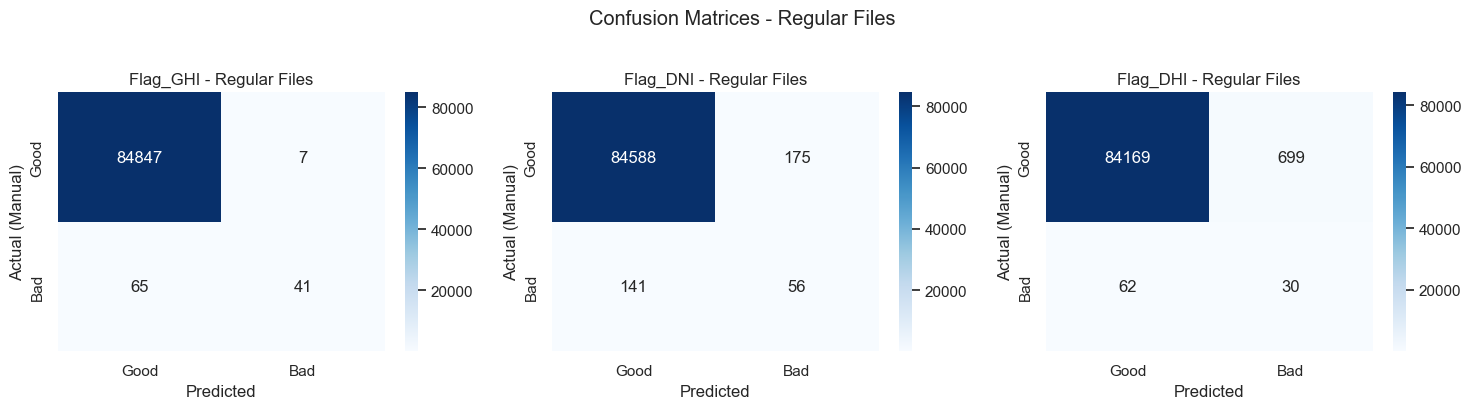

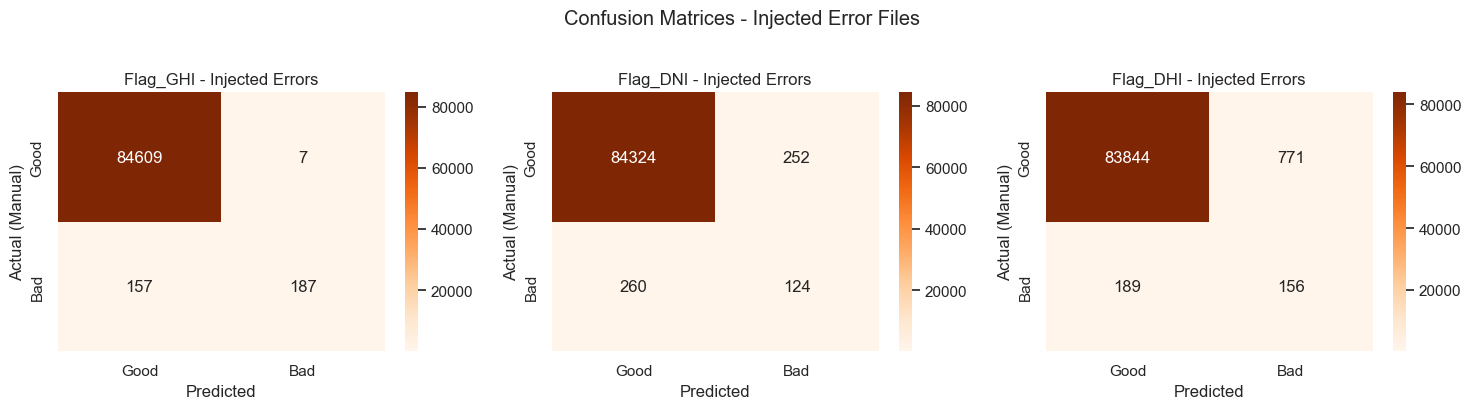

In [7]:
# Confusion matrices for regular files
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, target in enumerate(TARGETS):
    # Extract predicted and current flags for this target
    target_data = all_results_regular[all_results_regular["target"] == target]
    
    y_true = (target_data["current_flag"] == 99).astype(int)
    y_pred = (target_data["predicted_flag"] == 99).astype(int)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual (Manual)")
    ax.set_title(f"{target} - Regular Files")

plt.suptitle("Confusion Matrices - Regular Files", y=1.02)
plt.tight_layout()
plt.show()

# Confusion matrices for injected error files (if available)
if not all_results_injected.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for idx, target in enumerate(TARGETS):
        # Extract predicted and current flags for this target
        target_data = all_results_injected[all_results_injected["target"] == target]
        
        y_true = (target_data["current_flag"] == 99).astype(int)
        y_pred = (target_data["predicted_flag"] == 99).astype(int)
        
        # Compute confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, 
                    xticklabels=["Good", "Bad"], yticklabels=["Good", "Bad"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual (Manual)")
        ax.set_title(f"{target} - Injected Errors")
    
    plt.suptitle("Confusion Matrices - Injected Error Files", y=1.02)
    plt.tight_layout()
    plt.show()

## Step 3: Data Exploration - Bad Flags Over Time

Visualize manual vs model bad flags per day across the timeline.

Regular dataframe shape: (84960, 24)


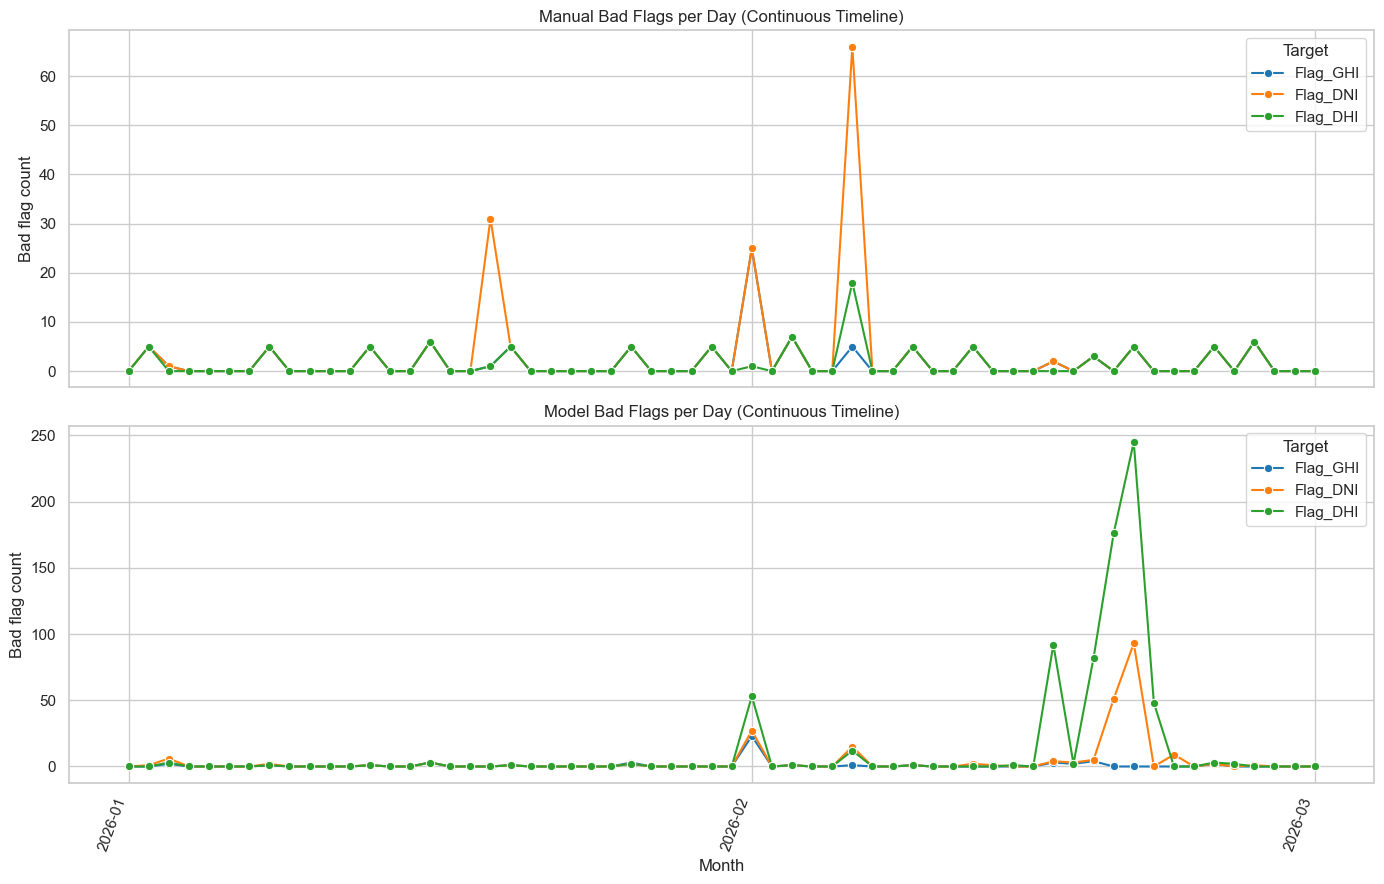

In [8]:
print(f"Regular dataframe shape: {df_regular.shape}")

# Fixed colors per target (shared across both plots)
palette = dict(zip(TARGETS, sns.color_palette("tab10", n_colors=len(TARGETS))))

# ----- Manual bad flags per day -----
manual_daily_rows = []
if TS_COL in df_regular.columns:
    df_regular[TS_COL] = pd.to_datetime(df_regular[TS_COL], errors="coerce")
    df_regular["day"] = df_regular[TS_COL].dt.floor("D")

    for target in TARGETS:
        if target in df_regular.columns:
            tmp = df_regular[["day", target]].dropna().copy()
            tmp["bad_count"] = tmp[target].eq(99).astype(int)
            agg = tmp.groupby("day", as_index=False)["bad_count"].sum()
            agg["target"] = target
            manual_daily_rows.append(agg)

manual_daily_counts = (
    pd.concat(manual_daily_rows, ignore_index=True)
    if manual_daily_rows
    else pd.DataFrame(columns=["day", "bad_count", "target"])
)

# ----- Model bad flags per day -----
model_daily_counts = pd.DataFrame(columns=["day", "bad_count", "target"])
if not all_results_regular.empty:
    model_df = all_results_regular[["_raw_ts", "target", "predicted_flag"]].copy()
    model_df["day"] = pd.to_datetime(
        model_df["_raw_ts"], format="%Y-%m-%d--%H:%M:%S", errors="coerce"
    ).dt.floor("D")
    model_df["bad_count"] = model_df["predicted_flag"].eq(99).astype(int)

    model_daily_counts = (
        model_df.groupby(["day", "target"], as_index=False)["bad_count"]
        .sum()
        .sort_values(["target", "day"])
    )

# ----- Build continuous x-axis -----
all_days = pd.concat(
    [
        manual_daily_counts["day"] if not manual_daily_counts.empty else pd.Series(dtype="datetime64[ns]"),
        model_daily_counts["day"] if not model_daily_counts.empty else pd.Series(dtype="datetime64[ns]"),
    ],
    ignore_index=True,
).dropna().drop_duplicates().sort_values()

day_to_idx = {d: i for i, d in enumerate(all_days)}

if not manual_daily_counts.empty:
    manual_daily_counts = manual_daily_counts.copy()
    manual_daily_counts["day_idx"] = manual_daily_counts["day"].map(day_to_idx)

if not model_daily_counts.empty:
    model_daily_counts = model_daily_counts.copy()
    model_daily_counts["day_idx"] = model_daily_counts["day"].map(day_to_idx)

# Tick labels at first day of each month in selected data
if len(all_days) > 0:
    days_series = pd.Series(all_days).dropna()
    month_starts = (
        days_series.groupby(days_series.dt.to_period("M"))
        .min()
        .sort_values()
    )
    tick_pos = month_starts.map(day_to_idx).tolist()
    tick_labels = month_starts.dt.strftime("%Y-%m").tolist()
else:
    tick_pos = []
    tick_labels = []

# ----- Multiplot -----
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

if not manual_daily_counts.empty:
    sns.lineplot(
        data=manual_daily_counts,
        x="day_idx",
        y="bad_count",
        hue="target",
        hue_order=TARGETS,
        palette=palette,
        marker="o",
        ax=axes[0],
    )
    axes[0].set_title("Manual Bad Flags per Day (Continuous Timeline)")
    axes[0].set_ylabel("Bad flag count")
else:
    axes[0].text(0.5, 0.5, "No manual flag data found", ha="center", va="center")
    axes[0].set_title("Manual Bad Flags per Day (Continuous Timeline)")

if not model_daily_counts.empty:
    sns.lineplot(
        data=model_daily_counts,
        x="day_idx",
        y="bad_count",
        hue="target",
        hue_order=TARGETS,
        palette=palette,
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title("Model Bad Flags per Day (Continuous Timeline)")
    axes[1].set_ylabel("Bad flag count")
else:
    axes[1].text(0.5, 0.5, "No model prediction data found", ha="center", va="center")
    axes[1].set_title("Model Bad Flags per Day (Continuous Timeline)")

axes[1].set_xlabel("Month")
for ax in axes:
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=70, ha="right")
    ax.legend(title="Target", loc="upper right")

plt.tight_layout()
plt.show()

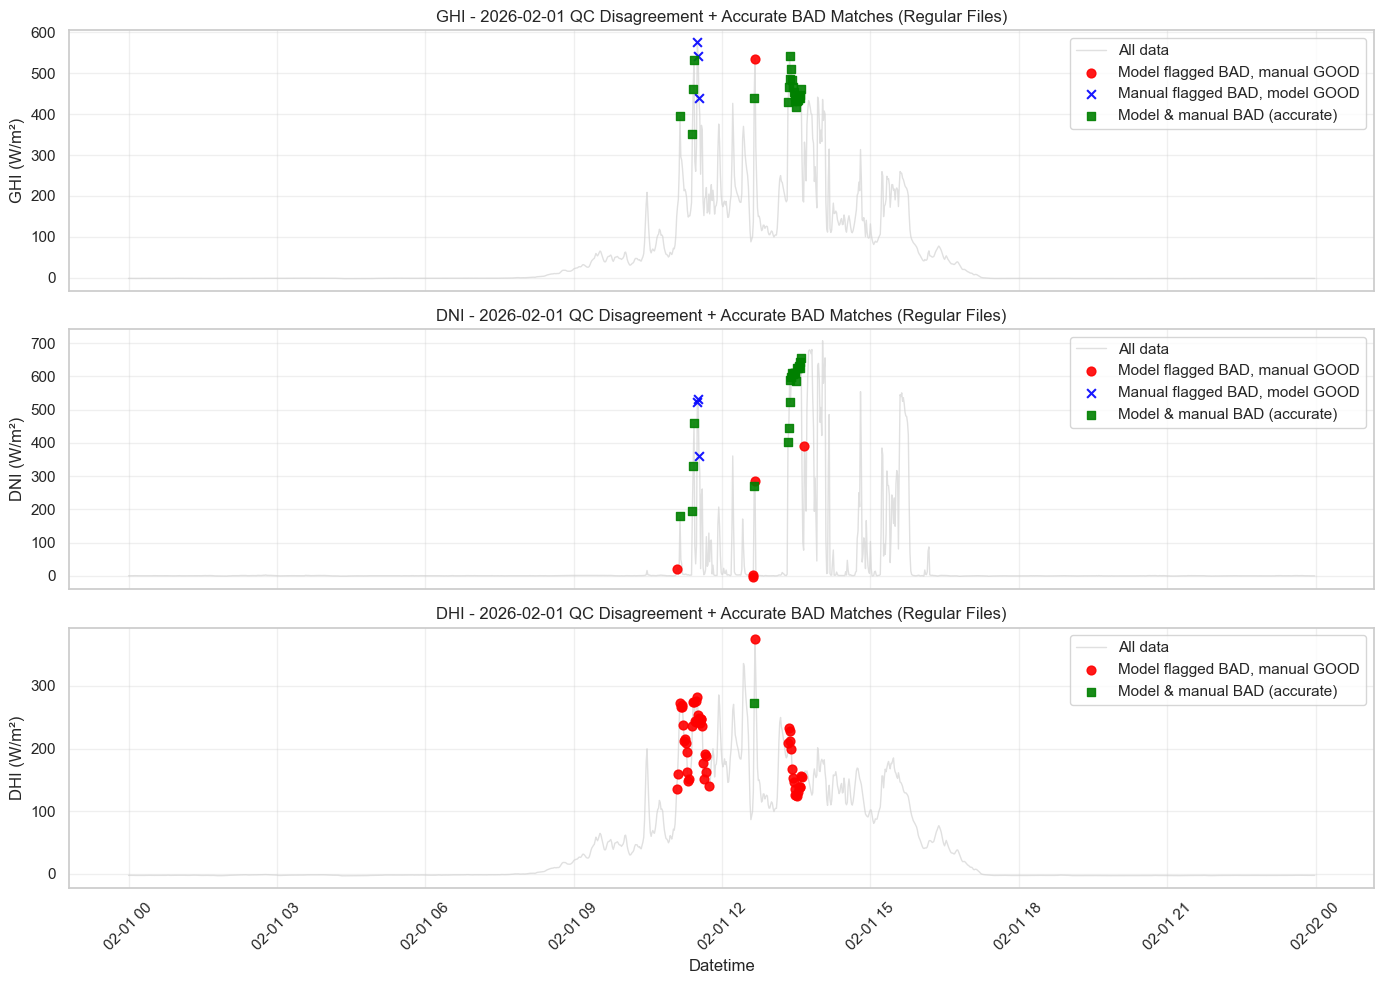

In [9]:
# Focus window - Regular Files
start_ts = "2026-02-01"
end_ts = "2026-02-02"

# Include both disagreements and accurate BAD matches in window
statuses_to_plot = ["model_only_bad", "manual_only_bad", "match_bad"]
day_points = all_results_regular[
    (all_results_regular["ts"] >= start_ts)
    & (all_results_regular["ts"] < end_ts)
    & (all_results_regular["status"].isin(statuses_to_plot))
].copy()

# Raw data in window
day_raw = df_regular[
    (df_regular["day"] >= start_ts) & (df_regular["day"] < end_ts)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
irradiance_cols = ["GHI", "DNI", "DHI"]

status_styles = {
    "model_only_bad": {"color": "red", "marker": "o", "label": "Model flagged BAD, manual GOOD"},
    "manual_only_bad": {"color": "blue", "marker": "x", "label": "Manual flagged BAD, model GOOD"},
    "match_bad": {"color": "green", "marker": "s", "label": "Model & manual BAD (accurate)"},
}

for idx, irr_col in enumerate(irradiance_cols):
    ax = axes[idx]

    # Base signal
    ax.plot(
        day_raw[TS_COL],
        day_raw[irr_col],
        color="lightgray",
        alpha=0.7,
        linewidth=1,
        label="All data",
    )

    # Overlay point types
    target_key = f"Flag_{irr_col}"
    target_points = day_points[day_points["target"] == target_key]

    for status, style in status_styles.items():
        pts = target_points[target_points["status"] == status]
        if not pts.empty:
            ax.scatter(
                pts["ts"],
                pts["irradiance_value"],
                c=style["color"],
                marker=style["marker"],
                s=40,
                alpha=0.9,
                label=style["label"],
                zorder=5,
            )

    ax.set_ylabel(f"{irr_col} (W/m²)")
    ax.set_title(f"{irr_col} - {start_ts} QC Disagreement + Accurate BAD Matches (Regular Files)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

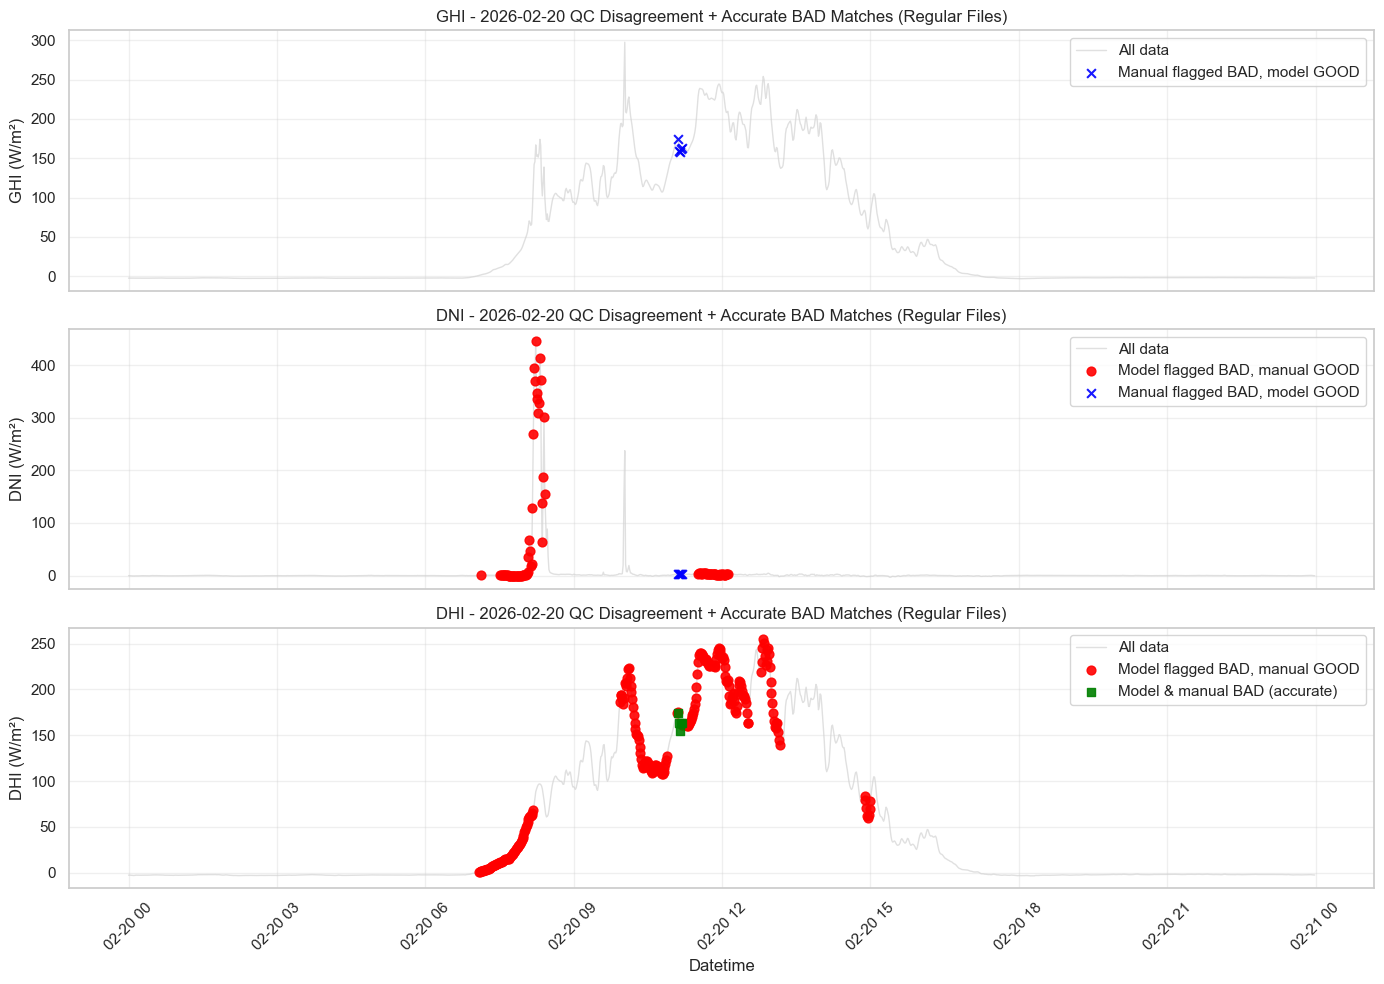

In [10]:
# Focus window - Regular Files
start_ts = "2026-02-20"
end_ts = "2026-02-21"

# Include both disagreements and accurate BAD matches in window
statuses_to_plot = ["model_only_bad", "manual_only_bad", "match_bad"]
day_points = all_results_regular[
    (all_results_regular["ts"] >= start_ts)
    & (all_results_regular["ts"] < end_ts)
    & (all_results_regular["status"].isin(statuses_to_plot))
].copy()

# Raw data in window
day_raw = df_regular[
    (df_regular["day"] >= start_ts) & (df_regular["day"] < end_ts)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
irradiance_cols = ["GHI", "DNI", "DHI"]

status_styles = {
    "model_only_bad": {"color": "red", "marker": "o", "label": "Model flagged BAD, manual GOOD"},
    "manual_only_bad": {"color": "blue", "marker": "x", "label": "Manual flagged BAD, model GOOD"},
    "match_bad": {"color": "green", "marker": "s", "label": "Model & manual BAD (accurate)"},
}

for idx, irr_col in enumerate(irradiance_cols):
    ax = axes[idx]

    # Base signal
    ax.plot(
        day_raw[TS_COL],
        day_raw[irr_col],
        color="lightgray",
        alpha=0.7,
        linewidth=1,
        label="All data",
    )

    # Overlay point types
    target_key = f"Flag_{irr_col}"
    target_points = day_points[day_points["target"] == target_key]

    for status, style in status_styles.items():
        pts = target_points[target_points["status"] == status]
        if not pts.empty:
            ax.scatter(
                pts["ts"],
                pts["irradiance_value"],
                c=style["color"],
                marker=style["marker"],
                s=40,
                alpha=0.9,
                label=style["label"],
                zorder=5,
            )

    ax.set_ylabel(f"{irr_col} (W/m²)")
    ax.set_title(f"{irr_col} - {start_ts} QC Disagreement + Accurate BAD Matches (Regular Files)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

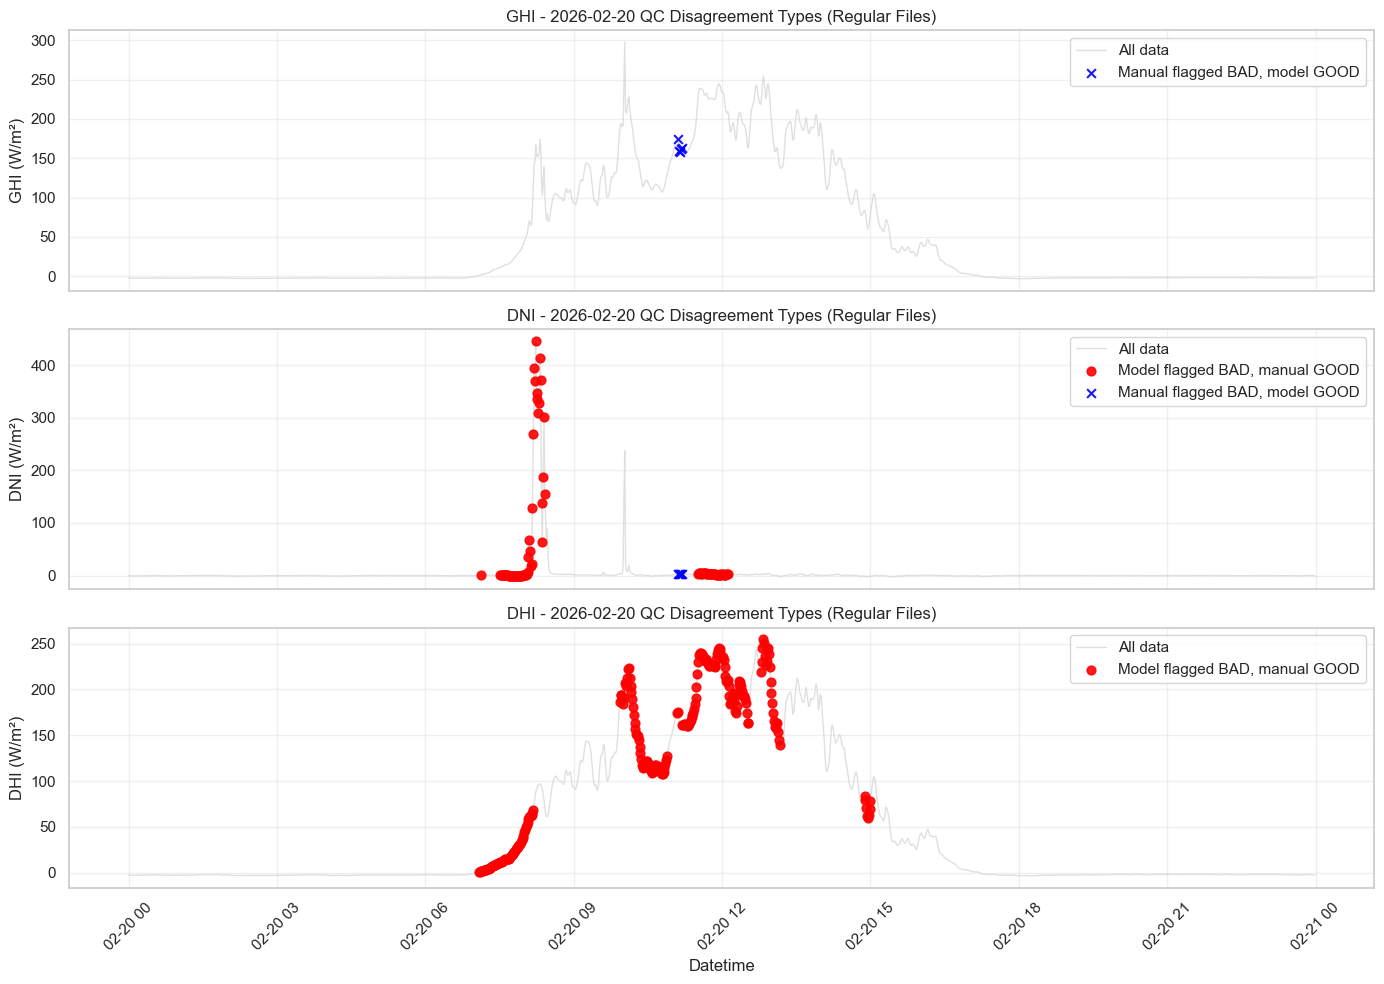

In [11]:
# Focus window - Regular Files (Disagreements Only)
start_ts = "2026-02-20"
end_ts = "2026-02-21"

# Disagreements in window
day_disagreements = disagreements_regular[
    (disagreements_regular["ts"] >= start_ts) & (disagreements_regular["ts"] < end_ts)
].copy()

# Raw data in window
day_raw = df_regular[
    (df_regular["day"] >= start_ts) & (df_regular["day"] < end_ts)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
irradiance_cols = ["GHI", "DNI", "DHI"]

status_styles = {
    "model_only_bad": {"color": "red", "marker": "o", "label": "Model flagged BAD, manual GOOD"},
    "manual_only_bad": {"color": "blue", "marker": "x", "label": "Manual flagged BAD, model GOOD"},
}

for idx, irr_col in enumerate(irradiance_cols):
    ax = axes[idx]

    # Base signal
    ax.plot(
        day_raw[TS_COL],
        day_raw[irr_col],
        color="lightgray",
        alpha=0.7,
        linewidth=1,
        label="All data",
    )

    # Overlay disagreement types separately
    target_key = f"Flag_{irr_col}"
    target_disagreements = day_disagreements[day_disagreements["target"] == target_key]

    for status, style in status_styles.items():
        pts = target_disagreements[target_disagreements["status"] == status]
        if not pts.empty:
            ax.scatter(
                pts["ts"],
                pts["irradiance_value"],
                c=style["color"],
                marker=style["marker"],
                s=40,
                alpha=0.9,
                label=style["label"],
                zorder=5,
            )

    ax.set_ylabel(f"{irr_col} (W/m²)")
    ax.set_title(f"{irr_col} - {start_ts} QC Disagreement Types (Regular Files)")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Datetime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 4: Analyze Injected Error Files

Explore model performance on files with artificially injected errors to test error detection capabilities.

Visualizing injected error data from 2026-01-01--00:01:00 to 2026-01-02 00:01:00


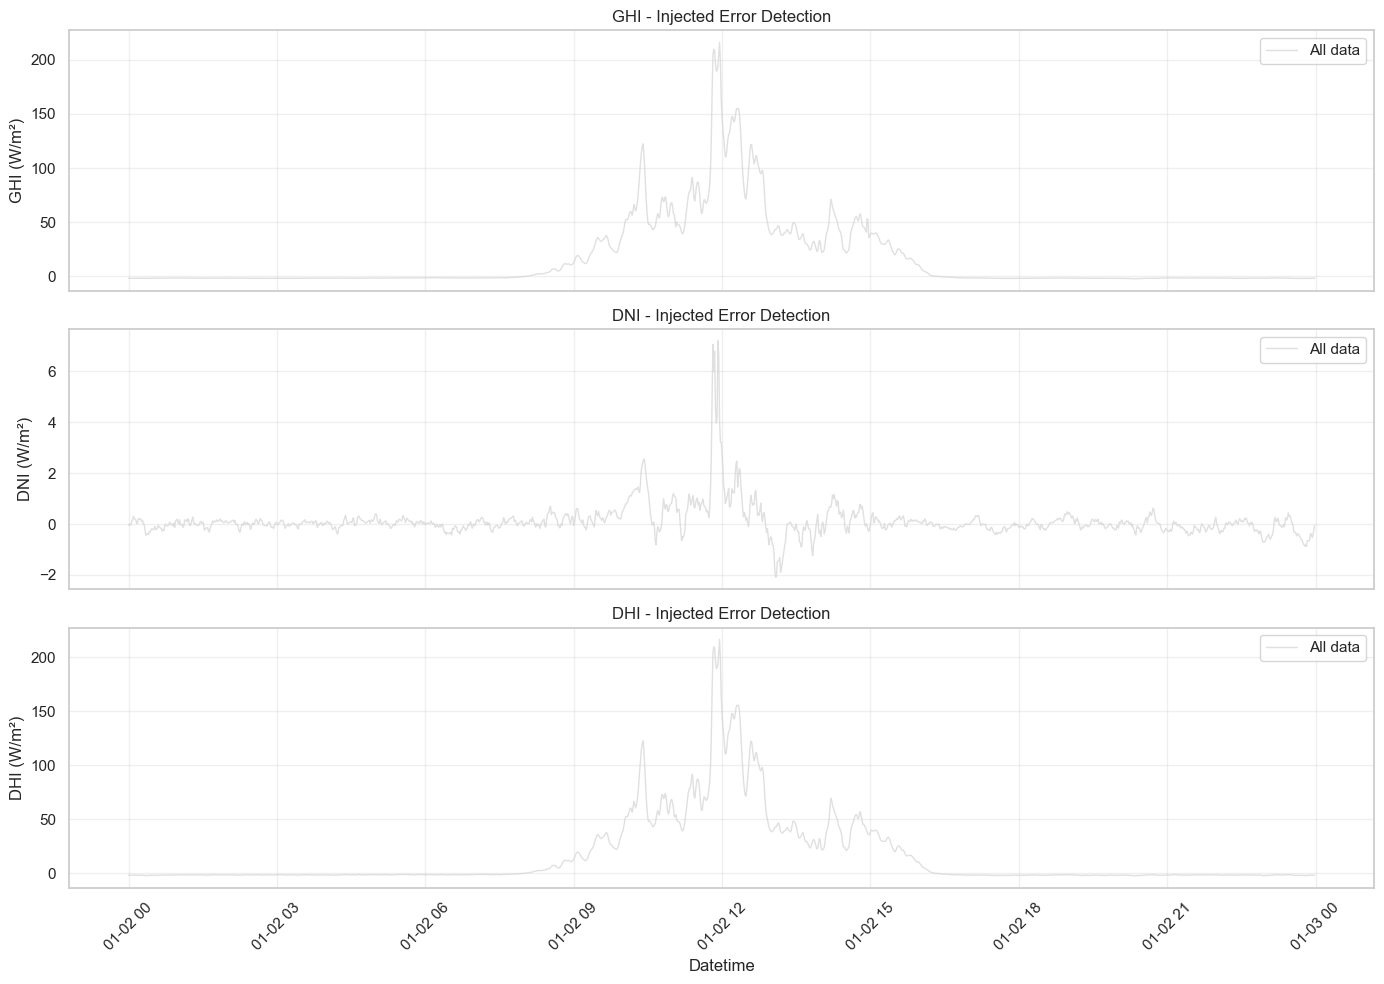

In [12]:
# Visualize injected error files if available
if not df_injected.empty and not all_results_injected.empty:
    # Pick a date range from the injected error files
    start_ts = df_injected[TS_COL].min()
    end_ts = pd.to_datetime(start_ts) + pd.Timedelta(days=1)
    
    print(f"Visualizing injected error data from {start_ts} to {end_ts}")
    
    # Include both disagreements and accurate BAD matches in window
    statuses_to_plot = ["model_only_bad", "manual_only_bad", "match_bad"]
    day_points = all_results_injected[
        (all_results_injected["ts"] >= start_ts)
        & (all_results_injected["ts"] < end_ts)
        & (all_results_injected["status"].isin(statuses_to_plot))
    ].copy()
    
    # Ensure day column exists
    if "day" not in df_injected.columns:
        df_injected[TS_COL] = pd.to_datetime(df_injected[TS_COL], errors="coerce")
        df_injected["day"] = df_injected[TS_COL].dt.floor("D")
    
    # Raw data in window
    day_raw = df_injected[
        (df_injected["day"] >= start_ts) & (df_injected["day"] < end_ts)
    ].copy()
    
    if not day_raw.empty:
        fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
        irradiance_cols = ["GHI", "DNI", "DHI"]
        
        status_styles = {
            "model_only_bad": {"color": "red", "marker": "o", "label": "Model flagged BAD, manual GOOD"},
            "manual_only_bad": {"color": "blue", "marker": "x", "label": "Manual flagged BAD, model GOOD"},
            "match_bad": {"color": "green", "marker": "s", "label": "Model & manual BAD (accurate)"},
        }
        
        for idx, irr_col in enumerate(irradiance_cols):
            ax = axes[idx]
        
            # Base signal
            ax.plot(
                day_raw[TS_COL],
                day_raw[irr_col],
                color="lightgray",
                alpha=0.7,
                linewidth=1,
                label="All data",
            )
        
            # Overlay point types
            target_key = f"Flag_{irr_col}"
            target_points = day_points[day_points["target"] == target_key]
        
            for status, style in status_styles.items():
                pts = target_points[target_points["status"] == status]
                if not pts.empty:
                    ax.scatter(
                        pts["ts"],
                        pts["irradiance_value"],
                        c=style["color"],
                        marker=style["marker"],
                        s=40,
                        alpha=0.9,
                        label=style["label"],
                        zorder=5,
                    )
        
            ax.set_ylabel(f"{irr_col} (W/m²)")
            ax.set_title(f"{irr_col} - Injected Error Detection")
            ax.grid(True, alpha=0.3)
            ax.legend()
        
        axes[-1].set_xlabel("Datetime")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No data in selected time window")
else:
    print("No injected error data available for visualization")

In [13]:
# Summary comparison between regular and injected error datasets
print("=" * 60)
print("SUMMARY COMPARISON: Regular vs Injected Error Files")
print("=" * 60)

print("\n REGULAR FILES:")
print(f"  - Shape: {df_regular.shape}")
print(f"  - Date range: {df_regular[TS_COL].min()} to {df_regular[TS_COL].max()}")
if not all_results_regular.empty:
    total = len(all_results_regular)
    good_match = len(all_results_regular[all_results_regular["status"] == "match_good"])
    bad_match = len(all_results_regular[all_results_regular["status"] == "match_bad"])
    model_only = len(all_results_regular[all_results_regular["status"] == "model_only_bad"])
    manual_only = len(all_results_regular[all_results_regular["status"] == "manual_only_bad"])
    print(f"  - Agreement rate: {100 * (good_match + bad_match) / total:.2f}%")
    print(f"  - Model-only bad flags: {model_only}")
    print(f"  - Manual-only bad flags: {manual_only}")

if not df_injected.empty:
    print("\n INJECTED ERROR FILES:")
    print(f"  - Shape: {df_injected.shape}")
    print(f"  - Date range: {df_injected[TS_COL].min()} to {df_injected[TS_COL].max()}")
    if not all_results_injected.empty:
        total = len(all_results_injected)
        good_match = len(all_results_injected[all_results_injected["status"] == "match_good"])
        bad_match = len(all_results_injected[all_results_injected["status"] == "match_bad"])
        model_only = len(all_results_injected[all_results_injected["status"] == "model_only_bad"])
        manual_only = len(all_results_injected[all_results_injected["status"] == "manual_only_bad"])
        print(f"  - Agreement rate: {100 * (good_match + bad_match) / total:.2f}%")
        print(f"  - Model-only bad flags: {model_only}")
        print(f"  - Manual-only bad flags: {manual_only}")
else:
    print("\n INJECTED ERROR FILES: None available")

print("\n" + "=" * 60)

SUMMARY COMPARISON: Regular vs Injected Error Files

 REGULAR FILES:
  - Shape: (84960, 25)
  - Date range: 2026-01-01 00:01:00 to 2026-03-01 00:00:00
  - Agreement rate: 99.55%
  - Model-only bad flags: 881
  - Manual-only bad flags: 268

 INJECTED ERROR FILES:
  - Shape: (84960, 25)
  - Date range: 2026-01-01 00:01:00 to 2026-03-01 00:00:00
  - Agreement rate: 99.36%
  - Model-only bad flags: 1030
  - Manual-only bad flags: 606

